In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import openpyxl as px
import os
import joblib

import warnings
warnings.filterwarnings('ignore')

#### Load the dataset

In [2]:
path = "/Users/stevenschepanski/Documents/04_ANALYSIS/GreenSpaces"

In [3]:
# Read data from the CSV files into data frames
rob = pd.read_excel(path + "/data/RiskBias_graphs_GreenSpace.xlsx")

In [4]:
# Define output directory
out_dir = os.path.join(path, "graphs")
os.makedirs(out_dir, exist_ok=True)

#### Check the dataset

In [5]:
rob.head()

,Author,Selection bias (Random sequence),Selection bias (Allocation),Reporting bias,Other bias,Performance bias,Detection bias,Attrition bias
0,Detweiler 2015,Unclear,Unclear,High,Unclear,High,High,Low
1,Shin 2012,Unclear,Unclear,High,Unclear,High,Unclear,Unclear
2,Hyvönen 2023,Unclear,Unclear,High,High,High,High,Low
3,Yeon 2022,Low,Low,Unclear,High,High,High,High
4,Watkins-Martin 2022,Low,High,High,High,Low,Low,High


In [6]:
# Extract year from "Author" column
rob['Year'] = rob['Author'].str.extract('(\d{4})').astype(int)

# Sort DataFrame by year
rob = rob.sort_values('Year')

# Drop the "Year" column
rob = rob.drop(columns='Year')

# Display the DataFrame
rob.head()

,Author,Selection bias (Random sequence),Selection bias (Allocation),Reporting bias,Other bias,Performance bias,Detection bias,Attrition bias
10,Taylor & Kuo 2009,Unclear,Unclear,High,High,High,High,Unclear
17,Kam and Siu 2010,Unclear,Unclear,High,Unclear,High,Low,Low
14,Luk 2011,Unclear,Unclear,Unclear,Unclear,High,Unclear,Unclear
1,Shin 2012,Unclear,Unclear,High,Unclear,High,Unclear,Unclear
0,Detweiler 2015,Unclear,Unclear,High,Unclear,High,High,Low


#### Overview table 1

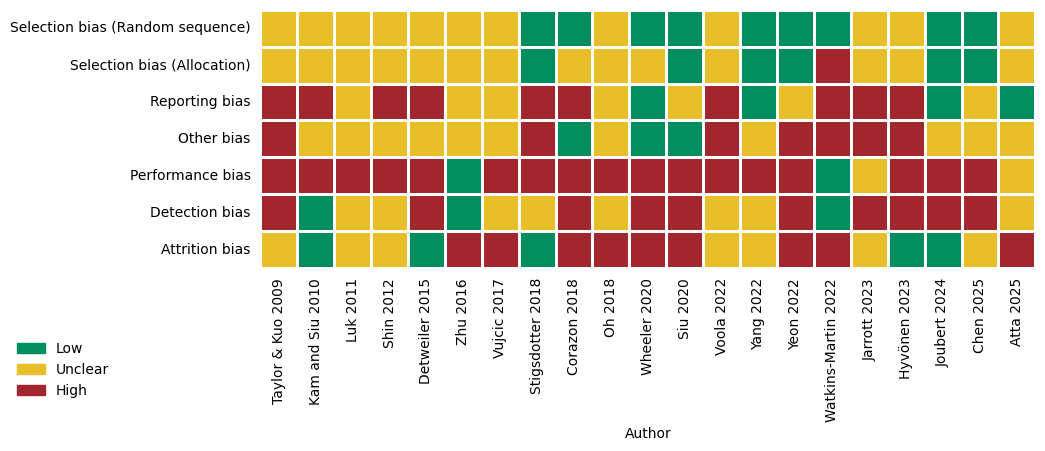

In [7]:
import matplotlib.patches as mpatches
# -------------------------------------------------
# Clean & recode rob table for plotting
# -------------------------------------------------
# Strip trailing spaces (safe for mixed dtypes)
rob_clean = rob.applymap(lambda x: x.strip() if isinstance(x, str) else x).copy()

# Replace 'Low', 'Unclear', 'High' with numeric codes
rob_clean.replace({'Low': 0, 'Unclear': 1, 'High': 2}, inplace=True)

# -------------------------------------------------
# Define colormap (Low / Unclear / High)
# -------------------------------------------------
cmap_dict = {0: '#008e5e', 1: '#e8bf28', 2: '#a1262d'}
cmap = [cmap_dict[i] for i in range(3)]

# -------------------------------------------------
# Create figure FIRST
# -------------------------------------------------
fig1, ax = plt.subplots(figsize=(10, 8))

# -------------------------------------------------
# Heatmap
# -------------------------------------------------
sns.heatmap(
    rob_clean.set_index('Author').T,
    cmap=cmap,
    annot=False,
    cbar=False,
    linewidths=1,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax
)

# Remove ticks (keep labels)
ax.tick_params(left=False, bottom=False)

# -------------------------------------------------
# Legend
# -------------------------------------------------
low_patch = mpatches.Patch(color=cmap_dict[0], label='Low')
unclear_patch = mpatches.Patch(color=cmap_dict[1], label='Unclear')
high_patch = mpatches.Patch(color=cmap_dict[2], label='High')

ax.legend(
    handles=[low_patch, unclear_patch, high_patch],
    loc='lower left',
    bbox_to_anchor=(-0.33, -0.55),
    frameon=False
)

# -------------------------------------------------
# Save figure
# -------------------------------------------------
for ext in ["png", "pdf", "eps"]:
    fig1.savefig(
        os.path.join(out_dir, f"risk_of_bias_heatmap.{ext}"),
        dpi=300,
        bbox_inches="tight"
    )

# -------------------------------------------------
# Show & clean up
# -------------------------------------------------
plt.show()
plt.close(fig1)


#### Overview table 2

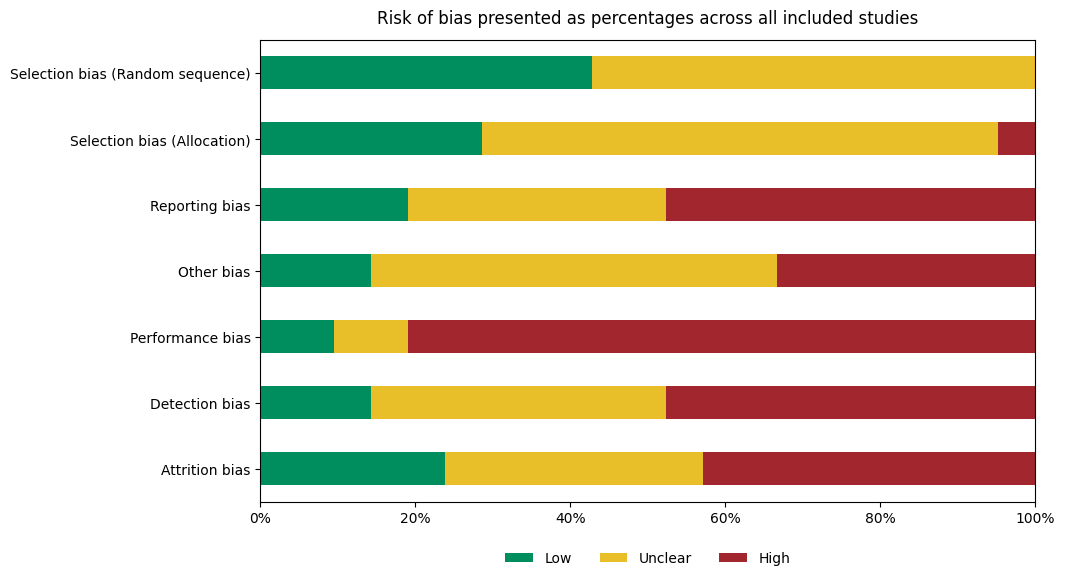

In [10]:
# -------------------------------------------------
# Calculate percentages (ROBUST version – fixes white gap)
# -------------------------------------------------
risk_levels = ["Low", "Unclear", "High"]

# Work on a clean copy
rob_pct = rob.copy()

# Strip whitespace and standardise labels
for col in rob_pct.columns:
    if col != "Author":
        rob_pct[col] = (
            rob_pct[col]
            .astype(str)
            .str.strip()
            .str.capitalize()
        )

# Now compute percentages
percentages = (
    rob_pct.drop(columns="Author")
           .apply(lambda s: s.value_counts(normalize=True)
                           .reindex(risk_levels, fill_value=0))
)

# Transpose so rows = bias domains, columns = Low/Unclear/High
percentages_plot = percentages.T

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig2, ax = plt.subplots(figsize=(10, 6))

# -------------------------------------------------
# Plot stacked horizontal bar chart
# -------------------------------------------------
percentages_plot.iloc[::-1].plot(
    kind="barh",
    stacked=True,
    color={"Low": "#008e5e", "Unclear": "#e8bf28", "High": "#a1262d"},
    ax=ax
)

# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])

ax.set_title("Risk of bias presented as percentages across all included studies", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")

# -------------------------------------------------
# Legend (force correct order)
# -------------------------------------------------
handles, labels = ax.get_legend_handles_labels()
order = [labels.index("Low"), labels.index("Unclear"), labels.index("High")]
ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

# -------------------------------------------------
# Save figure
# -------------------------------------------------
for ext in ["png", "pdf", "eps"]:
    fig2.savefig(
        os.path.join(out_dir, f"risk_of_bias_percentages.{ext}"),
        dpi=300,
        bbox_inches="tight"
    )

# -------------------------------------------------
# Show & clean up
# -------------------------------------------------
plt.show()
plt.close(fig2)